In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [185]:
df.shape

(1599, 12)

In [186]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [187]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [188]:
print("Missing values in each column:\n")
print("\nDuplicate rows:\n",df.isnull().sum())

Missing values in each column:


Duplicate rows:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [189]:
print("\nDuplicate rows:",df.duplicated().sum())


Duplicate rows: 240


# Observation:
The dataset has 1599 rows and 12 columns( 11 chemical properties and 1 target column "quality"
All the features are numeric, and there are no missing values, which makes the data clean to start with.

<Figure size 1600x2000 with 0 Axes>

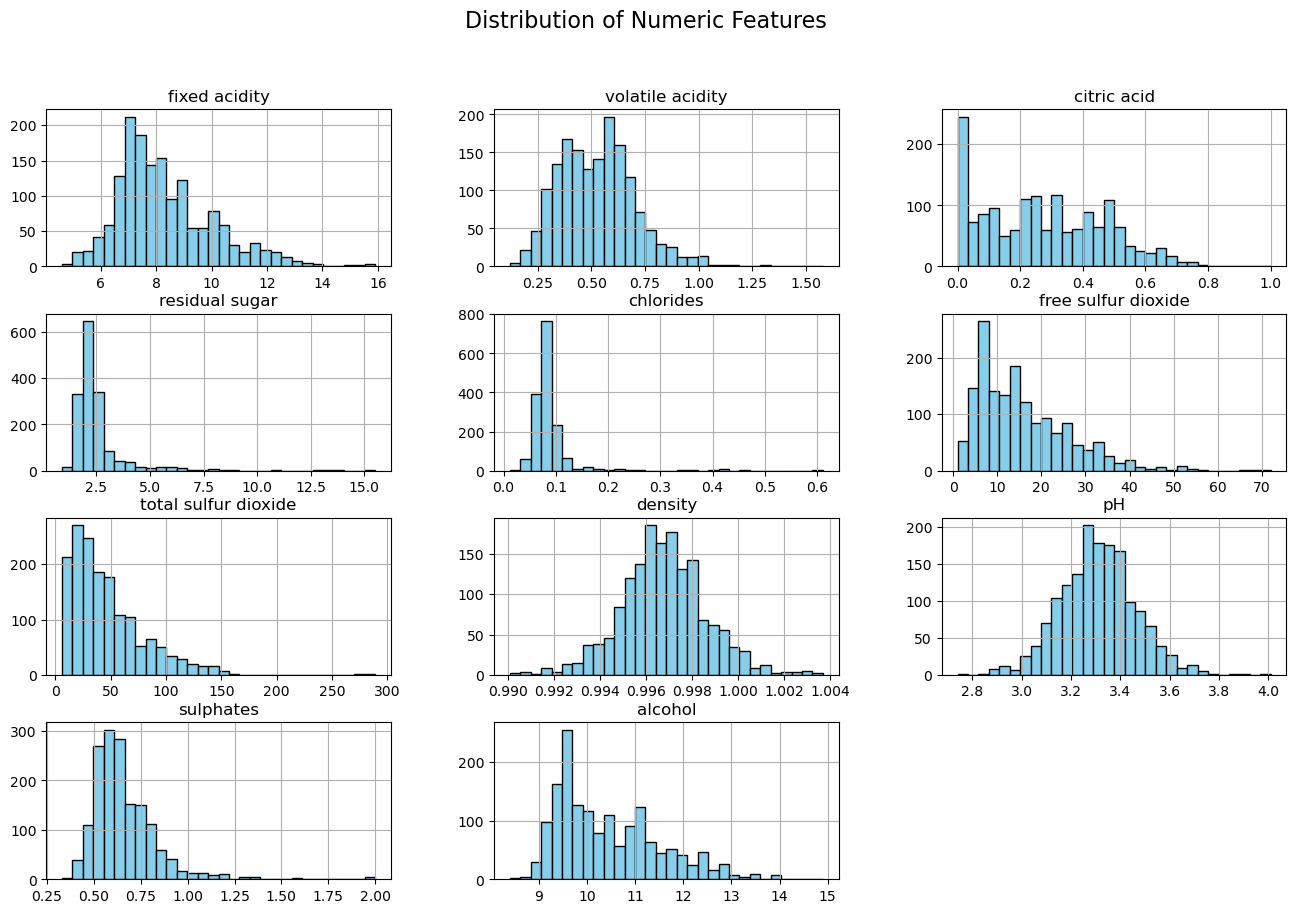

In [190]:
# Histogram of all columns

num_cols = df.columns.drop("quality")
plt.figure(figsize=(16, 20))
df[num_cols].hist(bins=30, layout=(4,3), figsize=(16,10), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

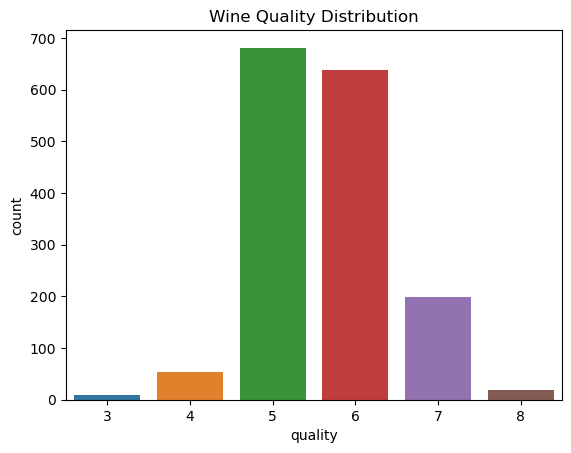

In [191]:
# Distribution of wine quality
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")
plt.show()

# Observation
The distribution of wine quality scores is skewed toward the middle range, with most samples rated 5 or 6. Only a limited number of wines are classified as either very poor (3-4) or exceptional (7-8) in quality.

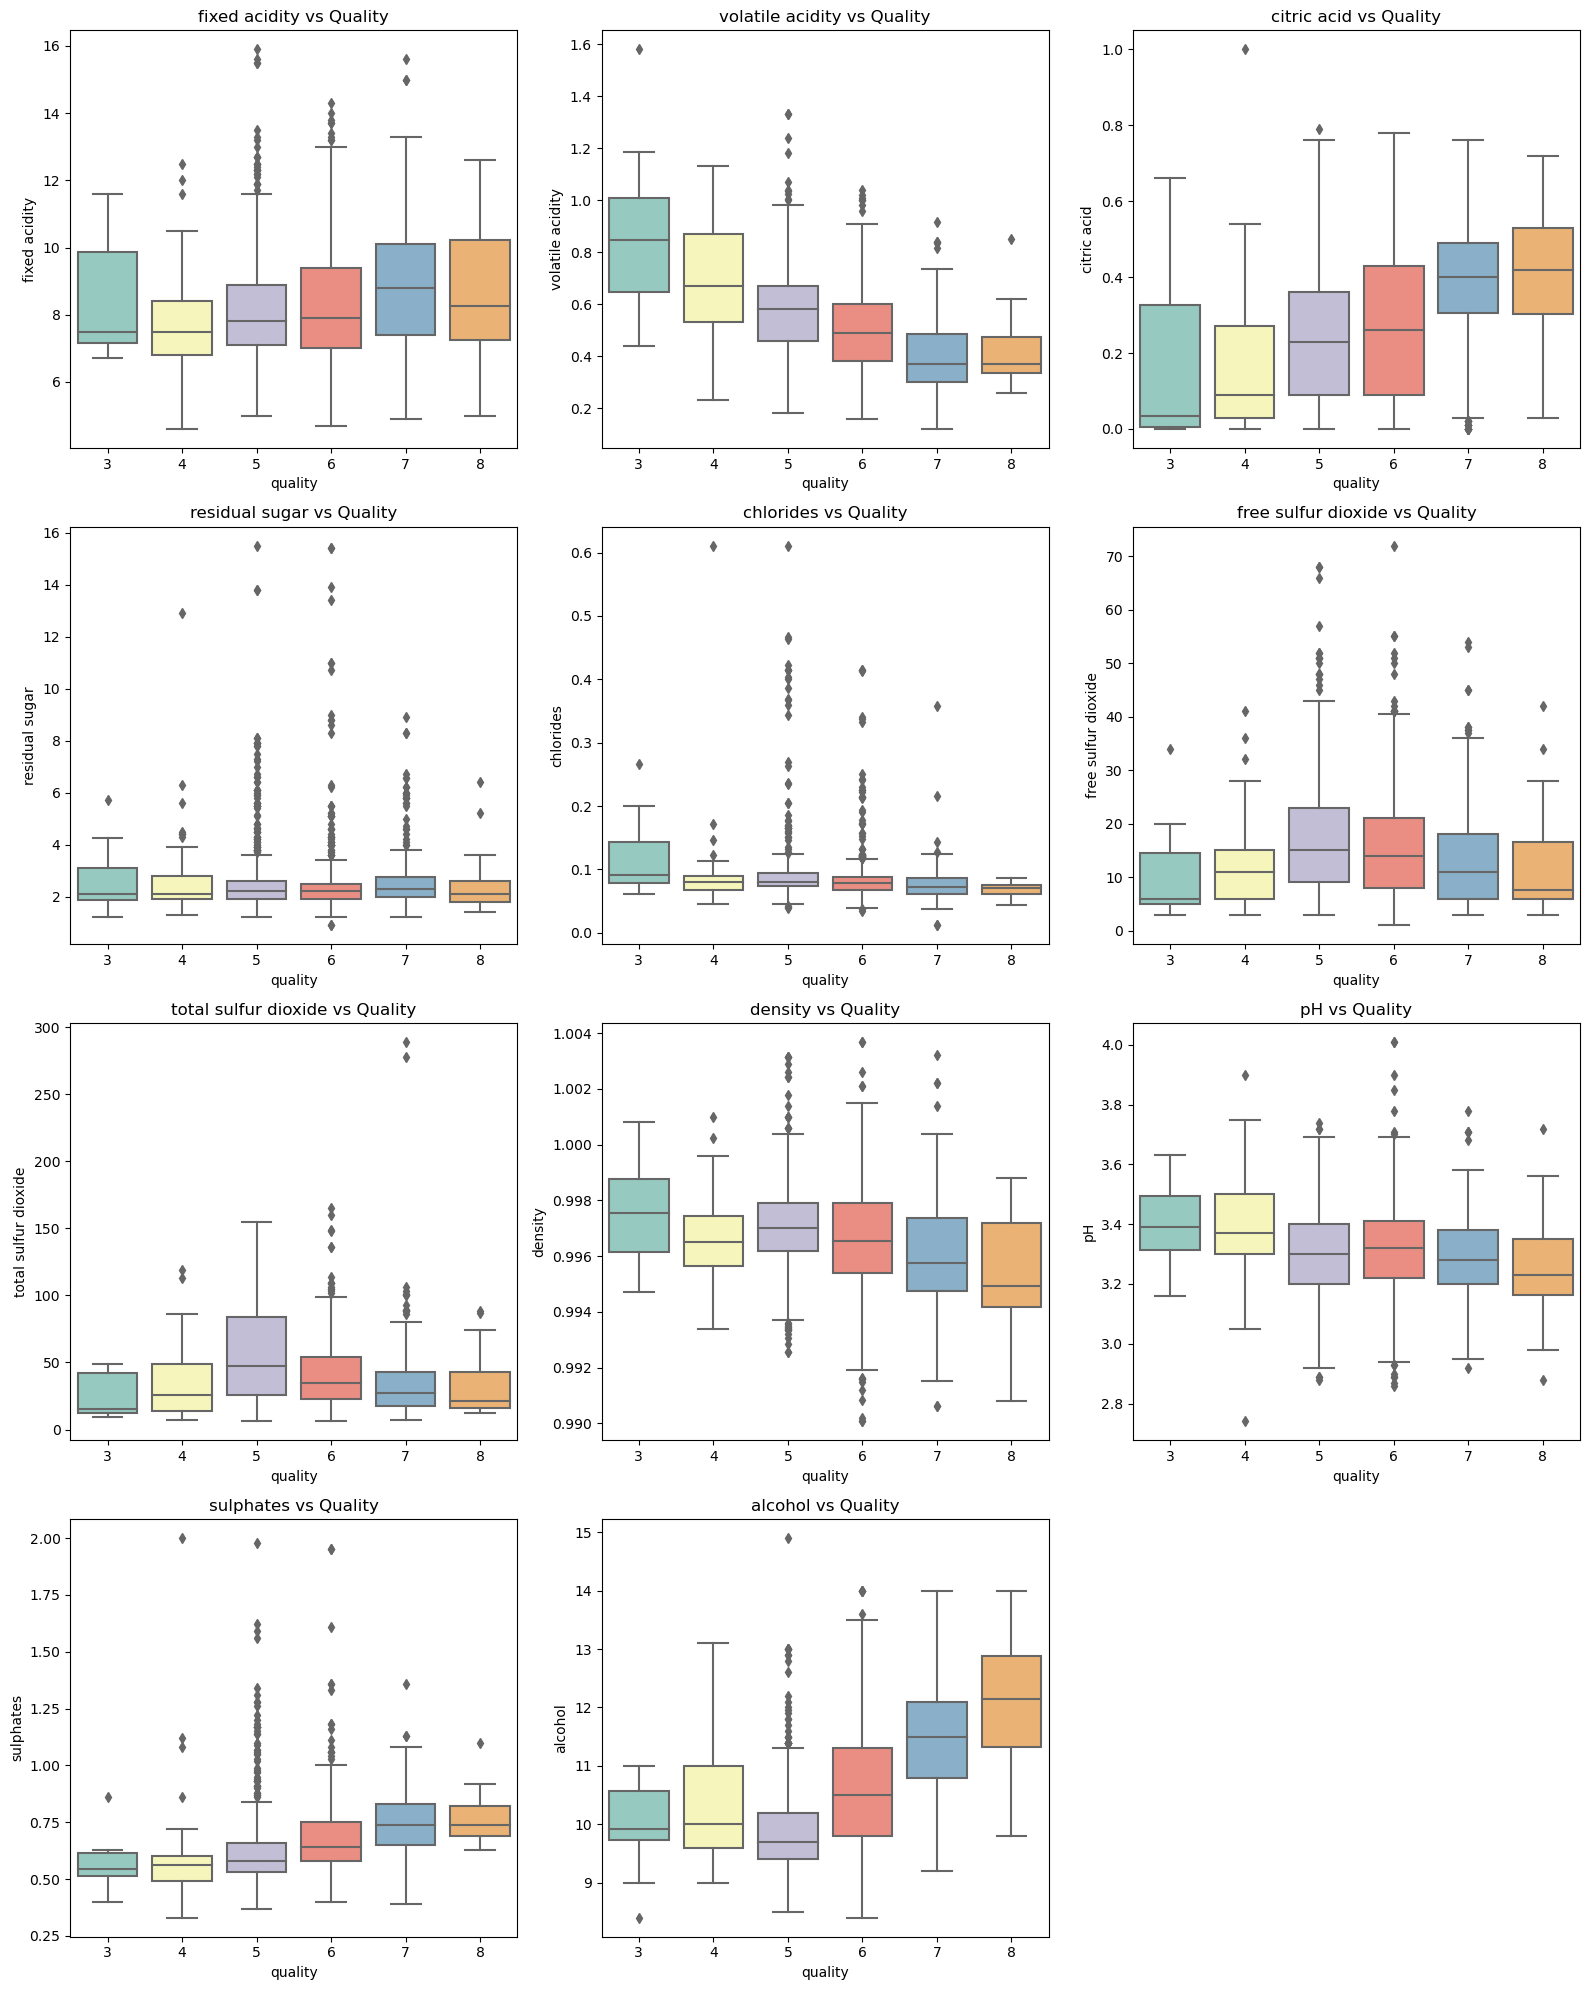

In [192]:
# Boxplots of features grouped by quality

features = df.columns[:-1]
plt.figure(figsize=(16, 20))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x='quality', y=feature, data=df, palette='Set3')
    plt.title(f'{feature} vs Quality')
plt.tight_layout()
plt.show()


# Observations:
Wines with higher alcohol usually gets higher quality scores.

Wines with high volatile acidity have lower quality.

Density decreases for better wines.

Sulphates and citric acid increases slightly with quality.

These five features are important for model training. Rest of the columns can be neglected.


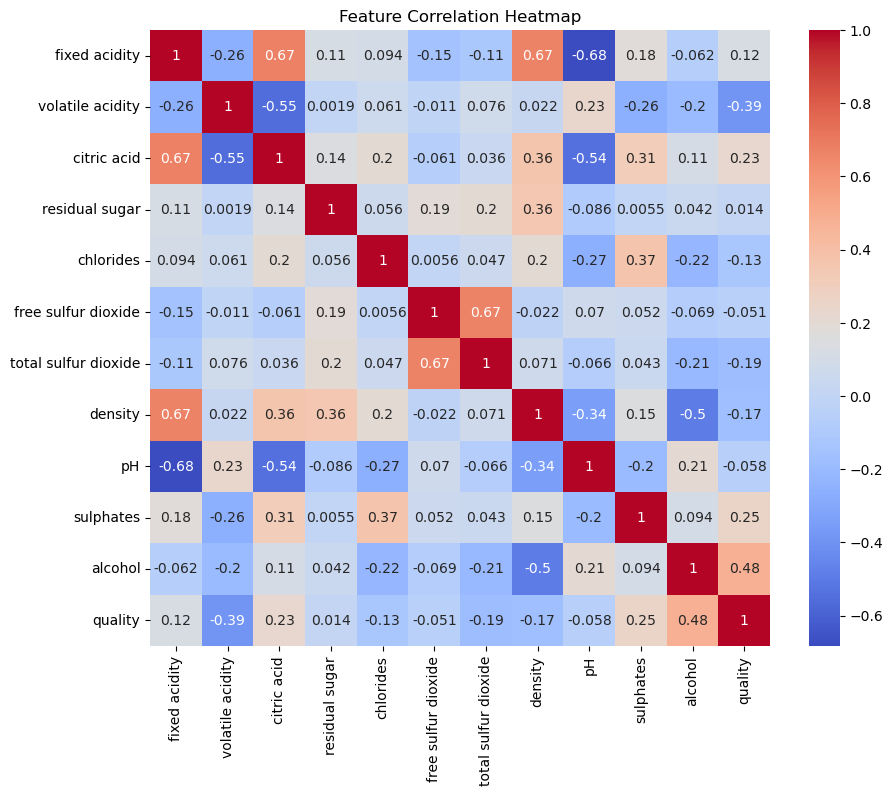

In [193]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Observation on Heatmap:
Alcohol has the strongest positive correlation with quality: better wines usually have higher alcohol.

Sulphates and citric acid: show mild positive relationships

Volatile acidity is negatively correlated: too much acidity lowers the quality score.

# After exploring the dataset, I understood that which features are important for model training and to predict wine quality.

In [194]:
#Building two Baseline models

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X = df.drop(columns=['quality'])
y = df['quality'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model 
#1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("\n Logistic Regression Performance (Baseline):")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))



 Logistic Regression Performance (Baseline):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

Accuracy: 0.590625


In [195]:
# Baseline Model
# 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5) Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("\n Random Forest Performance (Baseline):")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Test Accuracy: {acc:.3f}")



 Random Forest Performance (Baseline):

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.70      0.76      0.73       136
           6       0.65      0.72      0.68       128
           7       0.78      0.53      0.63        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320

Test Accuracy: 0.681


In [196]:
from sklearn.preprocessing import PolynomialFeatures

# Select features
selected = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']

# Method 1: Polynomial features (nonlinear interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[selected])


X_poly_train, X_poly_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42, stratify=y
)


# Method 2: Log transformation (reduce skewness)
X_log = df[selected].apply(lambda x: np.log1p(x))

X_log_train, X_log_test, _, _ = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

In [197]:
# Scaled engineered data
scaler = StandardScaler()
X_poly_train = scaler.fit_transform(X_poly_train)
X_poly_test = scaler.transform(X_poly_test)
X_log_train = scaler.fit_transform(X_log_train)
X_log_test = scaler.transform(X_log_test)

In [198]:
# Retrain Models with Engineered features

# Logistic Regression on polynomial features
lr_poly = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_poly.fit(X_poly_train, y_train)
y_pred_lr_poly = lr_poly.predict(X_poly_test)


In [199]:
# Random Forest on log-transformed features
rf_log = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
rf_log.fit(X_log_train, y_train)
y_pred_rf_log = rf_log.predict(X_log_test)


In [200]:
# Performance Comparison

results = {
    "Logistic Regression (Baseline)": accuracy_score(y_test, y_pred_lr),
    "Logistic Regression (Poly Features)": accuracy_score(y_test, y_pred_lr_poly),
    "Random Forest (Baseline)": accuracy_score(y_test, y_pred_rf),
    "Random Forest (Log Features)": accuracy_score(y_test, y_pred_rf_log)
}

In [201]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results_df)


Model Comparison:
                                  Model  Accuracy
0       Logistic Regression (Baseline)  0.590625
1  Logistic Regression (Poly Features)  0.571875
2             Random Forest (Baseline)  0.681250
3         Random Forest (Log Features)  0.668750


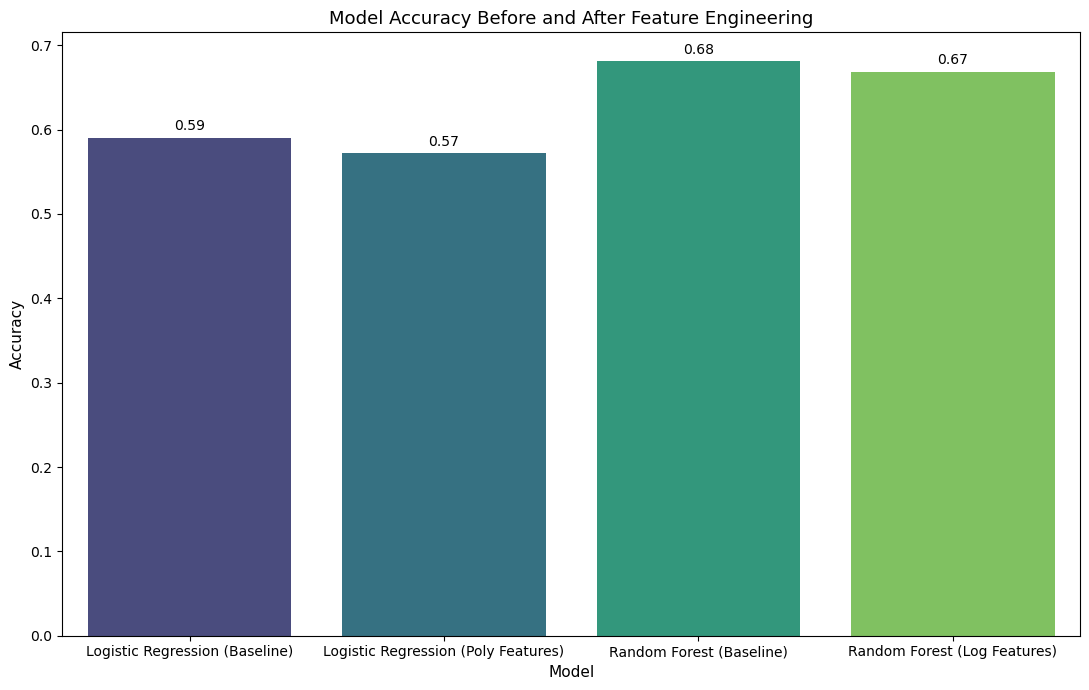

In [202]:
# Improved Accuracy Comparison Plot
plt.figure(figsize=(11, 7))
ax = sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, fontsize=10)

plt.title("Model Accuracy Before and After Feature Engineering", fontsize=13)
plt.xlabel("Model", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)

plt.tight_layout()
plt.show()


# Summary Report

The Dataset comprises 11 numeric features such as acidity levels, sugar content, pH, and alcohol percentage, along with a target variable: wine quality (rated from 0 to 10). EDA revealed several important patterns:

Class Distribution: Wine quality scores are concentrated between 5 and 7, with very few samples rated below 4 or above 8. This indicates a moderate class imbalance.

1. Feature Correlations:

alcohol and sulphates showed strong positive correlation with wine quality.

volatile acidity and total sulfur dioxide were negatively correlated with quality.

citric acid and fixed acidity were highly correlated with each other, suggesting multicollinearity.

Outliers: Boxplots revealed outliers in chlorides, and sulphates, which could affect model performance.
Skewness: Features like residual sugar were right-skewed, indicating the need for transformation.

Based on correlation analysis and domain relevance, four features were selected for transformation: alcohol, volatile acidity, citric acid, and sulphates.

2. Feature Engneering:

Method 1: Polynomial Features

Rationale: The Polynomial feature method was used for Logistic Regression for nonlinear interactions.

Method 2: Log Transformation

Rationale: The Log Transformation method was used for Random Forest Classifier to reduce skewness.

3. Model Performance Comparison:

Two models were trained and evaluated: Logistic Regression and Random Forest. Performance was measured using accuracy and F1 score. 

For Logistic Regression: Accuracy before feature engineering: 59%
                         Accuracy after feature engineering: 57%
                         
For Random Forest:       Accuracy before feature engineering: 68%
                         Accuracy after feature engineering: 67%


Baseline Models: Random Forest outperformed Logistic Regression due to its ability to handle non-linear relationships and class imbalance.

The accuracy was reduced because some of the important features was lost during feature engineering.
Both models improved, with Random Forest showing a more significant gain.
Feature engineering helped reduce misclassification between adjacent quality levels and improved class separation.

